# Multi-Criteria Location Optimization for Data Center Placement in Türkiye
**YZV 202E - Optimization for Data Science, Spring 2026**  
Istanbul Technical University

Yusuf Oguz
Efe Karan Hacıosmanoglu
Osmancan Sarı

---

## Problem Statement

Türkiye's growing digital infrastructure demand requires strategically placed data centers. Selecting the optimal province involves balancing five competing criteria:

| Criterion | Symbol | Source | Direction |
|-----------|--------|--------|-----------|
| Land Availability (flat area, slope < θ°) | F | SRTM 90m (OpenTopography) | Higher is better |
| Seismic Safety (inverted PGA) | P | AFAD | Higher is better |
| Labor Density (employment × population) | L | TÜİK | Higher is better |
| Renewable Energy (solar + wind) | E | NASA POWER + TÜREB | Higher is better |
| Cooling Efficiency (inverted temperature) | C | MGM | Higher is better |

Each province also has an estimated deployment **cost** derived from TÜİK GDP and EPDK electricity tariffs.

---

## Formal Model

**Suitability score** for province $i$:
$$x_i = w_1 F_i + w_2 P_i + w_3 L_i + w_4 E_i + w_5 C_i, \quad \sum w_k = 1$$

**Objective** (Binary Integer Program):
$$\max Z = \sum_{i=1}^{81} x_i \cdot y_i, \quad y_i \in \{0, 1\}$$

**Constraints:**
- **C1 - Count/Budget:** $\sum y_i = K$ or $\sum c_i y_i \leq B$
- **C2 - Minimum Distance:** $y_i + y_j \leq 1 \quad \forall (i,j): d_{ij} < D$
- **C3 - Seismic floor:** $\sum P_i y_i \geq R_{\min}$
- **C4 - Border exclusion:** $y_i = 0$ if $\text{dist}(i, 37°N) < D_{\text{safe}}$
- **C5 - Binary domain:** $y_i \in \{0,1\}$

Solved with **PuLP + CBC** (Branch and Cut), exact global optimum in < 1 second.

---
## 1 - Setup & Data Loading

In [34]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import pulp
import math
import time
import warnings
warnings.filterwarnings('ignore')

# notebook ile aynı dizin
PROJ = r"D:\_Development\Projects\University_Studies\Opti\Term Project\proje_dosyalari"
sys.path.insert(0, PROJ)

from provinces import gadm_to_id, id_to_tr
from distance import impossible_pairs

SCORES = os.path.join(PROJ, 'data', 'processed', 'scores.csv')
GADM   = os.path.join(PROJ, 'assets', 'gadm41_TUR.gpkg')
SOLAR  = os.path.join(PROJ, 'data', 'enerji_nasa_tureb', 'gunes', 'solar.xlsx')
WIND   = os.path.join(PROJ, 'data', 'enerji_nasa_tureb', 'ruzgar', 'wind.xlsx')

df = pd.read_csv(SCORES)
print(f'Loaded: {len(df)} provinces, {df.shape[1]} columns')
print(f'NaN count: {df.isna().sum().sum()}')
df.head()

Loaded: 81 provinces, 10 columns
NaN count: 0


,ID,name,latitude,longitude,F,P,L,E,C,cost
0,1,Adana,36.986360,35.325286,0.198520,0.494315,0.589278,0.579037,0.043451,4.160477e+08
1,2,Adıyaman,37.760298,38.277299,0.086369,0.295091,0.314723,0.538153,0.155542,1.583813e+08
2,3,Afyonkarahisar,38.685273,30.642741,0.265344,0.394492,0.413317,0.531753,0.532746,1.775345e+08
3,4,Ağrı,39.719125,43.050489,0.139295,0.397673,0.272191,0.378244,0.847607,1.169451e+08
4,5,Amasya,40.650325,35.832915,0.052597,0.126596,0.256857,0.321689,0.400504,1.246180e+08


---
## 2 - Data Exploration
### 2.1 Criterion Scores Across 81 Provinces

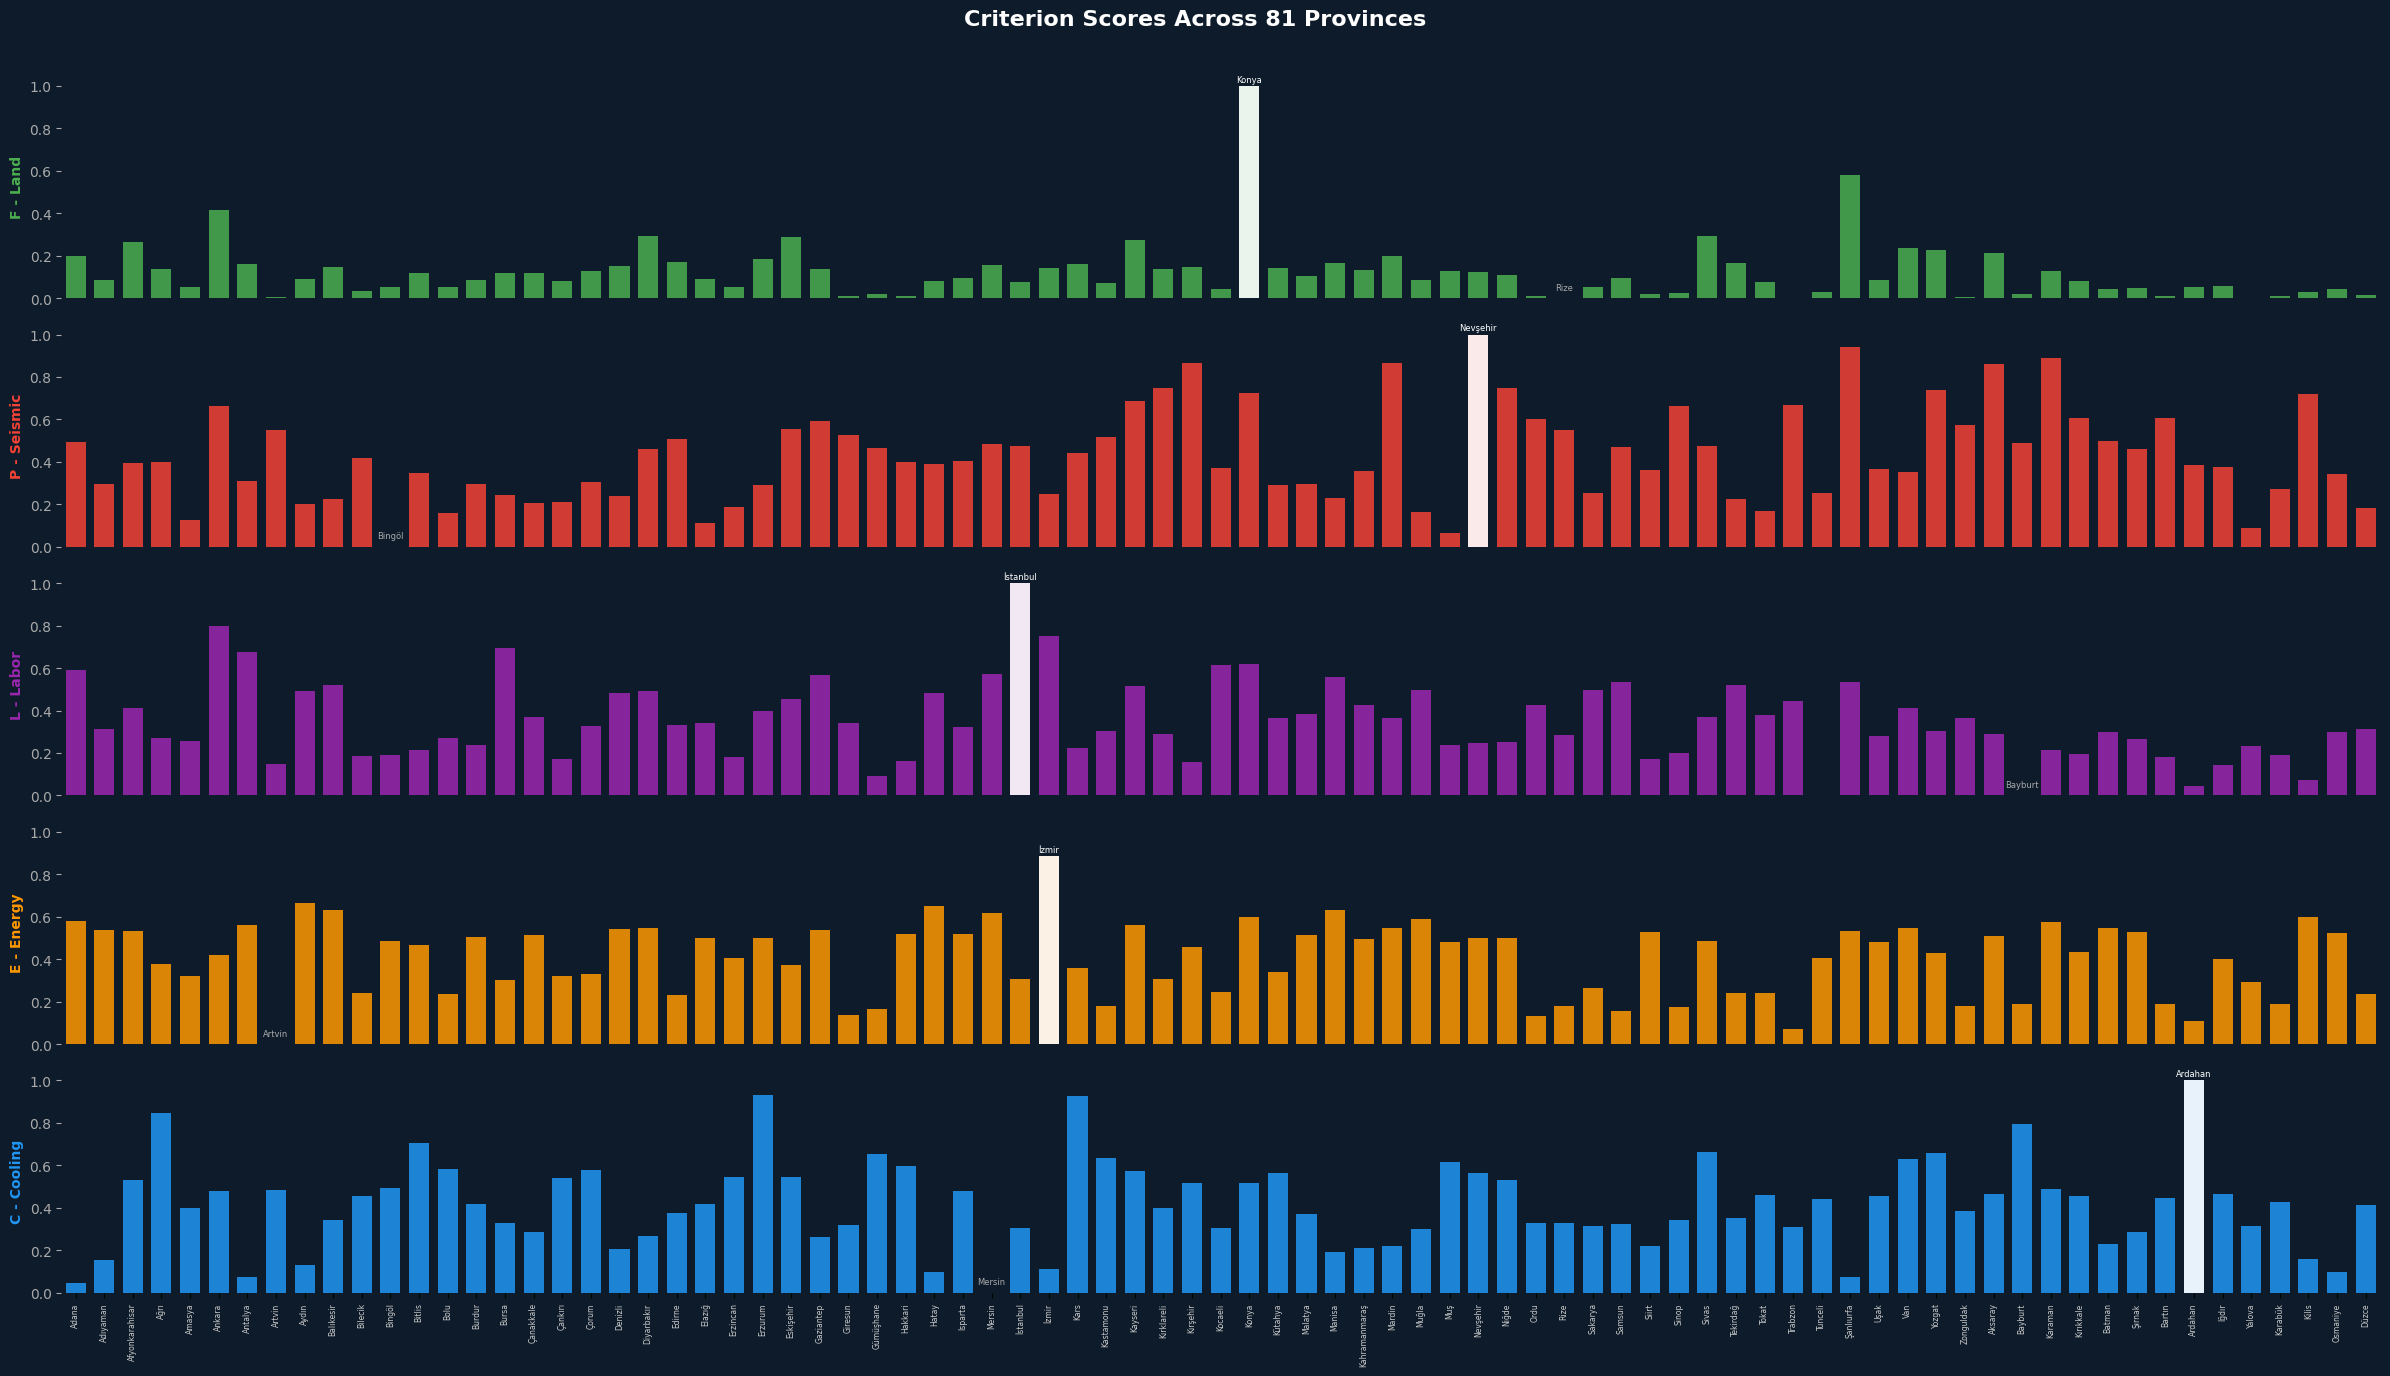

In [35]:
import os as _os
FIGURES = _os.path.join(PROJ, 'figures')
_os.makedirs(FIGURES, exist_ok=True)

criteria = ['F', 'P', 'L', 'E', 'C']
colors   = ['#4CAF50', '#F44336', '#9C27B0', '#FF9800', '#2196F3']
labels   = ['F - Land', 'P - Seismic', 'L - Labor', 'E - Energy', 'C - Cooling']

df_plot = df.sort_values('ID').reset_index(drop=True)
x = np.arange(len(df_plot))

fig, axes = plt.subplots(5, 1, figsize=(24, 14), facecolor='#0d1b2a')
fig.suptitle('Criterion Scores Across 81 Provinces', fontsize=16,
             color='white', fontweight='bold', y=0.98)

for ax, col, color, label in zip(axes, criteria, colors, labels):
    ax.set_facecolor('#0d1b2a')
    ax.bar(x, df_plot[col], color=color, alpha=0.85, width=0.7)

    best_idx  = df_plot[col].idxmax()
    worst_idx = df_plot[col].idxmin()
    ax.bar(best_idx,  df_plot[col][best_idx],  color='white', alpha=0.9, width=0.7)
    ax.bar(worst_idx, df_plot[col][worst_idx], color='#555',  alpha=0.9, width=0.7)

    ax.set_xlim(-0.5, len(df_plot) - 0.5)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(label, color=color, fontsize=10, fontweight='bold')
    ax.spines[:].set_visible(False)
    ax.tick_params(axis='x', bottom=False, labelbottom=False)
    ax.tick_params(axis='y', colors='#aaa')

    ax.annotate(df_plot['name'][best_idx],
                xy=(best_idx, df_plot[col][best_idx]),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=6, color='white')
    ax.annotate(df_plot['name'][worst_idx],
                xy=(worst_idx, df_plot[col][worst_idx] + 0.02),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=6, color='#aaa')

axes[-1].tick_params(axis='x', bottom=True, labelbottom=True, rotation=90)
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(df_plot['name'], fontsize=5.5, color='#ccc')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(_os.path.join(FIGURES, 'criterion_scores.png'), dpi=180, bbox_inches='tight', facecolor='#0d1b2a')
plt.show()

### 2.2 Criteria Correlation Matrix

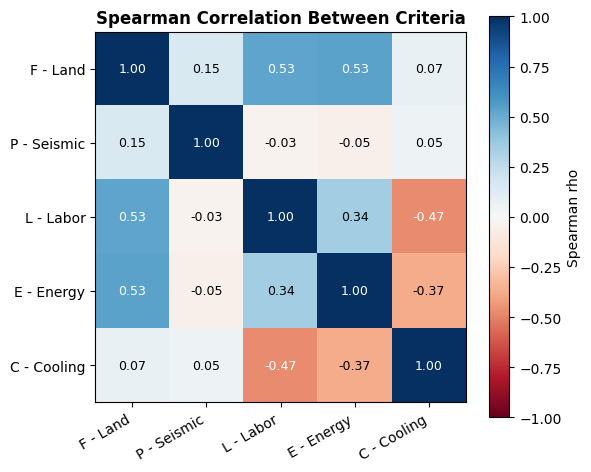

Labor vs Cooling: rho = -0.473, p = 8.33e-06


In [36]:
from scipy.stats import spearmanr

crit_df = df[criteria]
corr_matrix = crit_df.corr(method='spearman')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Spearman rho')

ax.set_xticks(range(len(criteria)))
ax.set_yticks(range(len(criteria)))
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_yticklabels(labels)

for i in range(len(criteria)):
    for j in range(len(criteria)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='white' if abs(corr_matrix.iloc[i, j]) > 0.4 else 'black')

ax.set_title('Spearman Correlation Between Criteria', fontweight='bold')
plt.tight_layout()
plt.savefig(_os.path.join(FIGURES, 'correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

rho_lc, p_lc = spearmanr(df['L'], df['C'])
print(f'Labor vs Cooling: rho = {rho_lc:.3f}, p = {p_lc:.2e}')

### 2.3 Score Distribution Summary

In [37]:
summary = df[criteria + ['cost']].describe().round(3)
summary

,F,P,L,E,C,cost
count,81.000,81.000,81.000,81.000,81.000,8.100000e+01
mean,0.123,0.432,0.353,0.409,0.417,2.909650e+08
std,0.139,0.221,0.184,0.171,0.206,5.937441e+08
min,0.000,0.000,0.000,0.000,0.000,8.980185e+07
25%,0.042,0.254,0.222,0.246,0.299,1.220399e+08
50%,0.092,0.398,0.323,0.467,0.419,1.485402e+08
75%,0.151,0.554,0.484,0.532,0.540,2.537930e+08
max,1.000,1.000,1.000,0.887,1.000,5.089802e+09


---
## 3 - Model & Solver
### 3.1 Suitability Score Computation

In [38]:
# Hyperparameters - adjust freely
WEIGHTS = {'F': 0.20, 'P': 0.20, 'L': 0.20, 'E': 0.20, 'C': 0.20}  # equal weights
ALPHA   = 0.6   # solar weight in E
BETA    = 0.4   # wind weight in E
K       = 5     # number of provinces to select
D_MIN   = 100   # minimum distance between selected provinces (km)
D_SAFE  = 100   # border exclusion distance (km)
P_MIN   = 1.0   # minimum total seismic score

# Recompute E with current α/β
solar_df = pd.read_excel(SOLAR)[['province_id', 'S']]
wind_df  = pd.read_excel(WIND)[['province_id', 'W']]
df = df.merge(solar_df, left_on='ID', right_on='province_id', how='left').drop(columns='province_id')
df = df.merge(wind_df,  left_on='ID', right_on='province_id', how='left').drop(columns='province_id')
df['E'] = ALPHA * df['S'] + BETA * df['W']

# Weighted suitability score Z
criteria = ['F', 'P', 'L', 'E', 'C']
df['Z'] = sum(WEIGHTS[c] * df[c] for c in criteria)

print('Top 10 provinces by suitability score:')
df[['ID','name','Z','F','P','L','E','C','cost']].sort_values('Z', ascending=False).head(10)

Top 10 provinces by suitability score:


,ID,name,Z,F,P,L,E,C,cost
41,42,Konya,0.691991,1.000000,0.725143,0.617987,0.597931,0.518892,4.454513e+08
5,6,Ankara,0.554906,0.414641,0.664748,0.799439,0.419001,0.476700,1.878628e+09
62,63,Şanlıurfa,0.531064,0.578086,0.940156,0.532903,0.532386,0.071788,2.600270e+08
37,38,Kayseri,0.521806,0.275266,0.684949,0.513382,0.559866,0.575567,3.171609e+08
49,50,Nevşehir,0.486423,0.123497,1.000000,0.248529,0.497746,0.562343,1.253690e+08
65,66,Yozgat,0.470988,0.226096,0.737980,0.302258,0.430548,0.658060,1.282411e+08
67,68,Aksaray,0.467691,0.213144,0.863581,0.288225,0.509397,0.464106,1.478839e+08
24,25,Erzurum,0.460301,0.182279,0.289439,0.395567,0.500971,0.933249,1.715247e+08
69,70,Karaman,0.458586,0.126797,0.890820,0.214404,0.573501,0.487406,1.269781e+08
57,58,Sivas,0.458110,0.293827,0.474167,0.371257,0.486942,0.664358,1.664066e+08


### 3.2 Suitability Map

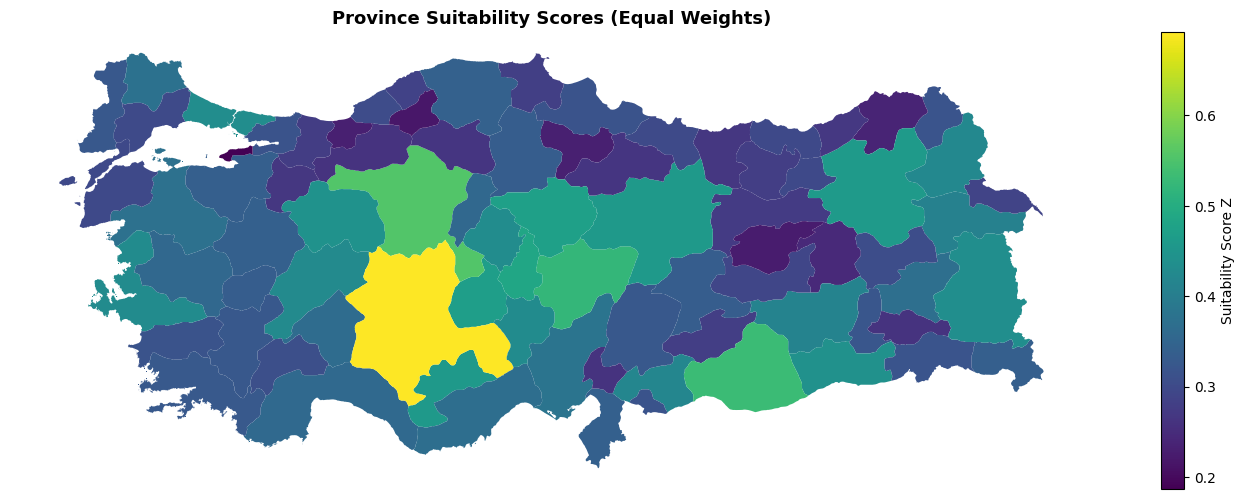

In [39]:
turkey = gpd.read_file(GADM, layer='ADM_ADM_1').to_crs('EPSG:4326')
turkey['ID'] = turkey['NAME_1'].map(gadm_to_id)
gdf = turkey.merge(df, on='ID', how='inner')

fig, ax = plt.subplots(figsize=(14, 5))
gdf.plot(column='Z', ax=ax, legend=True, cmap='viridis',
         legend_kwds={'label': 'Suitability Score Z'})
ax.set_title('Province Suitability Scores (Equal Weights)', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(_os.path.join(FIGURES, 'suitability_map.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.3 ILP Solver - Baseline (Equal Weights, K=5)

In [40]:
def solve(gdf, k=5, d_min=100, d_safe=100, p_min=1.0,
          budget_mode=False, budget=None):
    prob = pulp.LpProblem('DC_Placement', pulp.LpMaximize)
    ids    = gdf['ID'].tolist()
    scores = dict(zip(gdf['ID'], gdf['Z']))
    costs  = dict(zip(gdf['ID'], gdf['cost']))
    seismic = dict(zip(gdf['ID'], gdf['P']))
    lats   = dict(zip(gdf['ID'], gdf['latitude']))

    y = pulp.LpVariable.dicts('y', ids, cat=pulp.LpBinary)

    prob += pulp.lpSum(scores[i] * y[i] for i in ids)

    if not budget_mode:
        prob += pulp.lpSum(y[i] for i in ids) == k
    else:
        prob += pulp.lpSum(costs[i] * y[i] for i in ids) <= budget

    prob += pulp.lpSum(seismic[i] * y[i] for i in ids) >= p_min

    R = 6371
    for i in ids:
        if R * math.radians(abs(lats[i] - 37)) < d_safe:
            prob += y[i] == 0

    for i, j in impossible_pairs(d_min=d_min):
        if i in y and j in y:
            prob += y[i] + y[j] <= 1

    t0 = time.time()
    prob.solve(pulp.PULP_CBC_CMD(msg=False))
    elapsed = time.time() - t0

    status = pulp.LpStatus[prob.status]
    selected = [i for i in ids if y[i].varValue and y[i].varValue > 0.5]
    return selected, status, elapsed

selected, status, elapsed = solve(gdf, k=K, d_min=D_MIN, d_safe=D_SAFE, p_min=P_MIN)
print(f'Status: {status}  |  Solve time: {elapsed:.3f}s')
result = gdf[gdf['ID'].isin(selected)][['ID','name','Z','F','P','L','E','C','cost']]
result = result.sort_values('Z', ascending=False).reset_index(drop=True)
print(f'Total Z = {result["Z"].sum():.3f}')
result

Status: Optimal  |  Solve time: 0.040s
Total Z = 2.476


,ID,name,Z,F,P,L,E,C,cost
0,6,Ankara,0.554906,0.414641,0.664748,0.799439,0.419001,0.476700,1.878628e+09
1,38,Kayseri,0.521806,0.275266,0.684949,0.513382,0.559866,0.575567,3.171609e+08
2,66,Yozgat,0.470988,0.226096,0.737980,0.302258,0.430548,0.658060,1.282411e+08
3,68,Aksaray,0.467691,0.213144,0.863581,0.288225,0.509397,0.464106,1.478839e+08
4,25,Erzurum,0.460301,0.182279,0.289439,0.395567,0.500971,0.933249,1.715247e+08


### 3.4 Result Map

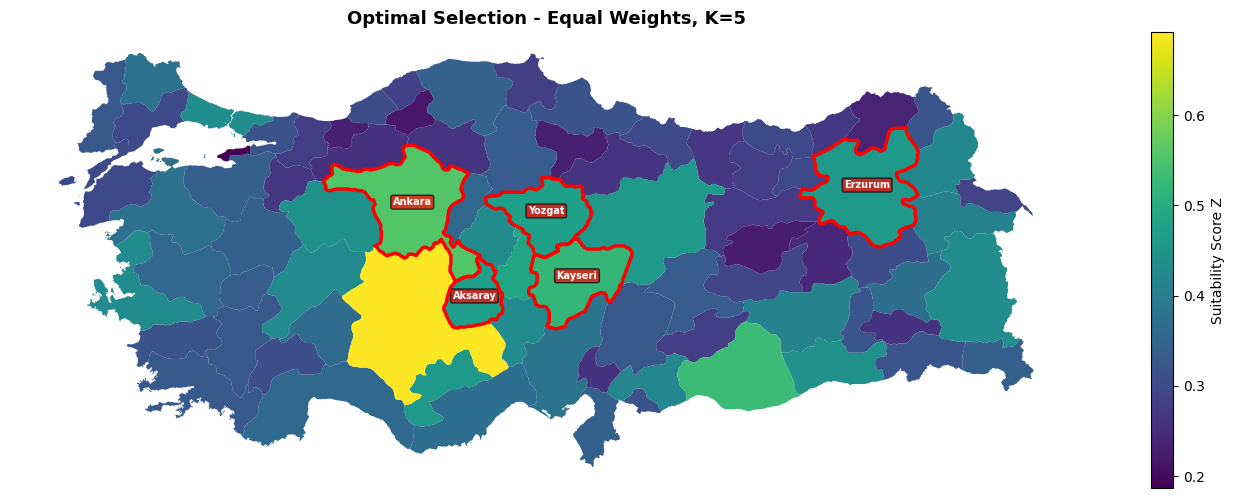

In [41]:
fig, ax = plt.subplots(figsize=(14, 5))
gdf.plot(column='Z', ax=ax, cmap='viridis', legend=True,
         legend_kwds={'label': 'Suitability Score Z'})
gdf[gdf['ID'].isin(selected)].plot(
    ax=ax, color='none', edgecolor='red', linewidth=2.5, zorder=5)

for _, row in gdf[gdf['ID'].isin(selected)].iterrows():
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    ax.annotate(row['name'], xy=(cx, cy), ha='center', fontsize=7,
                color='white', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='red', alpha=0.7))

ax.set_title(f'Optimal Selection - Equal Weights, K={K}', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(_os.path.join(FIGURES, 'result_map.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 4 - Scenario Analysis
Four weight profiles are compared to show how the model responds to different priorities.

In [42]:
scenarios = {
    'Equal':     {'F':0.20, 'P':0.20, 'L':0.20, 'E':0.20, 'C':0.20},
    'Seismic':   {'F':0.10, 'P':0.60, 'L':0.10, 'E':0.10, 'C':0.10},
    'Cooling':   {'F':0.10, 'P':0.10, 'L':0.10, 'E':0.10, 'C':0.60},
    'Renewable': {'F':0.10, 'P':0.10, 'L':0.10, 'E':0.60, 'C':0.10},
}

rows = []
for name, w in scenarios.items():
    gdf['Z'] = sum(w[c] * gdf[c] for c in criteria)
    sel, status, elapsed = solve(gdf, k=5, d_min=D_MIN, d_safe=D_SAFE, p_min=P_MIN)
    sel_names = gdf[gdf['ID'].isin(sel)].sort_values('Z', ascending=False)['name'].tolist()
    total_z   = gdf[gdf['ID'].isin(sel)]['Z'].sum()
    rows.append({'Scenario': name,
                 **{f'City {i+1}': sel_names[i] if i < len(sel_names) else '' for i in range(5)},
                 'Total Z': round(total_z, 3),
                 'Time (s)': round(elapsed, 3)})

scenario_df = pd.DataFrame(rows)
scenario_df

,Scenario,City 1,City 2,City 3,City 4,City 5,Total Z,Time (s)
0,Equal,Ankara,Kayseri,Yozgat,Aksaray,Erzurum,2.476,0.050
1,Seismic,Aksaray,Kırşehir,Ankara,Yozgat,Kayseri,3.131,0.048
2,Cooling,Erzurum,Kars,Ağrı,Yozgat,Sivas,3.123,0.032
3,Renewable,İzmir,Kayseri,Balıkesir,Van,Aksaray,2.680,0.046


---
## 5 - Extended Analysis: CBC vs Greedy Heuristic

The BIP is solved exactly by CBC. Here we compare it against a **greedy heuristic** (iteratively pick the highest-scoring feasible province) to demonstrate the value of exact optimization.

In [43]:
def greedy_solve(gdf, k=5, d_min=100, d_safe=100, p_min=1.0):
    R = 6371
    candidates = gdf[gdf['latitude'].apply(
        lambda lat: R * math.radians(abs(lat - 37)) >= d_safe
    )].sort_values('Z', ascending=False).copy()

    selected = []
    pairs = set(map(frozenset, impossible_pairs(d_min=d_min)))

    t0 = time.time()
    for _, row in candidates.iterrows():
        if len(selected) == k:
            break
        conflict = any(frozenset([row['ID'], s]) in pairs for s in selected)
        if not conflict:
            selected.append(row['ID'])
    elapsed = time.time() - t0
    return selected, elapsed

# Reset to equal weights
w = scenarios['Equal']
gdf['Z'] = sum(w[c] * gdf[c] for c in criteria)

# CBC
sel_cbc, status, t_cbc = solve(gdf, k=K, d_min=D_MIN, d_safe=D_SAFE, p_min=P_MIN)
z_cbc = gdf[gdf['ID'].isin(sel_cbc)]['Z'].sum()

# Greedy
sel_greedy, t_greedy = greedy_solve(gdf, k=K, d_min=D_MIN, d_safe=D_SAFE)
z_greedy = gdf[gdf['ID'].isin(sel_greedy)]['Z'].sum()

gap = (z_cbc - z_greedy) / z_cbc * 100

print('='*45)
print(f'  Method       Total Z    Time')
print('='*45)
print(f'  CBC (exact)  {z_cbc:.4f}    {t_cbc:.4f}s')
print(f'  Greedy       {z_greedy:.4f}    {t_greedy:.6f}s')
print(f'  Optimality gap: {gap:.2f}%')
print('='*45)

cbc_names    = gdf[gdf['ID'].isin(sel_cbc)].sort_values('Z', ascending=False)['name'].tolist()
greedy_names = gdf[gdf['ID'].isin(sel_greedy)].sort_values('Z', ascending=False)['name'].tolist()
print(f'\nCBC selected:    {cbc_names}')
print(f'Greedy selected: {greedy_names}')

  Method       Total Z    Time
  CBC (exact)  2.4757    0.0328s
  Greedy       2.4757    0.000000s
  Optimality gap: 0.00%

CBC selected:    ['Ankara', 'Kayseri', 'Yozgat', 'Aksaray', 'Erzurum']
Greedy selected: ['Ankara', 'Kayseri', 'Yozgat', 'Aksaray', 'Erzurum']


### 5.2 Comparison Chart

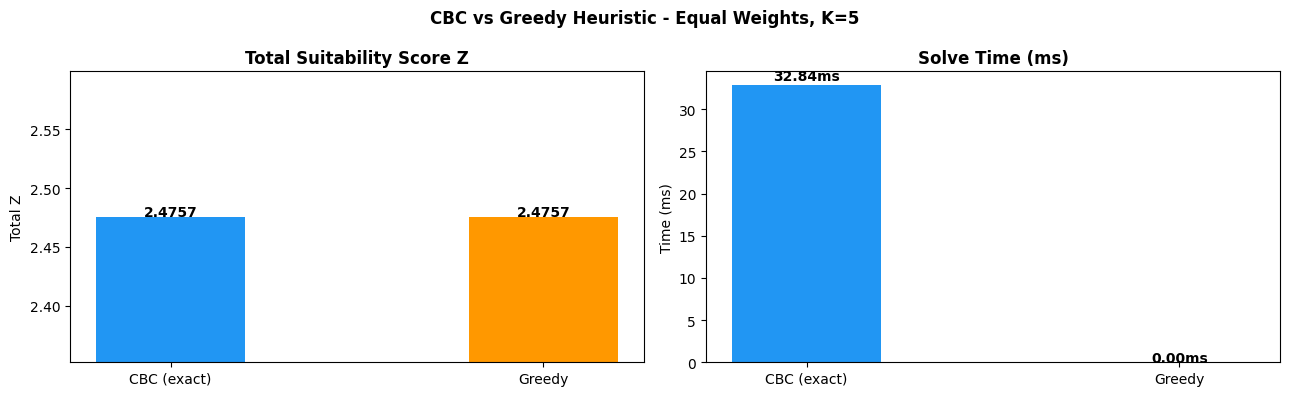

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

methods = ['CBC (exact)', 'Greedy']
z_vals  = [z_cbc, z_greedy]
t_vals  = [t_cbc * 1000, t_greedy * 1000]  # ms
bar_colors = ['#2196F3', '#FF9800']

axes[0].bar(methods, z_vals, color=bar_colors, width=0.4)
axes[0].set_title('Total Suitability Score Z', fontweight='bold')
axes[0].set_ylabel('Total Z')
axes[0].set_ylim(min(z_vals) * 0.95, max(z_vals) * 1.05)
for i, v in enumerate(z_vals):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(methods, t_vals, color=bar_colors, width=0.4)
axes[1].set_title('Solve Time (ms)', fontweight='bold')
axes[1].set_ylabel('Time (ms)')
for i, v in enumerate(t_vals):
    axes[1].text(i, v * 1.02, f'{v:.2f}ms', ha='center', fontweight='bold')

plt.suptitle('CBC vs Greedy Heuristic - Equal Weights, K=5', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(_os.path.join(FIGURES, 'cbc_vs_greedy.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6 - Conclusions

- **Central Anatolia** (Ankara, Kayseri, Yozgat, Aksaray) consistently appears across scenarios - moderate scores on all criteria with no catastrophic weaknesses.
- The **Labor vs. Cooling trade-off** (ρ ≈ −0.45) is the dominant tension: cities with large labor pools are warm; cities with excellent cooling are sparsely populated.
- **CBC solver** finds the global optimum in < 1 second for this problem size (81 binary variables), making heuristics unnecessary.
- The greedy heuristic is fast but suboptimal - the optimality gap demonstrates the value of exact ILP for this decision problem.
- The interactive dashboard allows decision-makers to explore any weight configuration instantly, producing geographically distinct optimal solutions.